In [ ]:
import json
import os
from PIL import Image
import pandas as pd
#import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter
from collections import defaultdict
import random
import shutil
#from torchvision import transforms
from sklearn.decomposition import PCA
from skimage.feature import hog, local_binary_pattern
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### 1. Geschaeftsverstaendnis 

#### 1.1 Ausgangslage und Problemstellung

Das Wolframinertgas-Schweißen (WIG bzw. TIG) ist ein in der Automobil- und Flugzeugbranche weit verbreitetes Verfahren für das dauerhafte Verbinden verschiedenster Metalle. Die Qualitaet ist fuer die Sicherheit von entscheidender Bedeutung. 

Die Kontrolle dieser Schweißnaehte erfolgt entweder manuell ueber Pruefpersonal, das speziell auf diese Thematik geschult wurde oder zerstoerungsfreie Prüfverfahren, worunter u.a. Ultraschall- oder Röntgenverfahren fallen. Die erste Variante ist von subjektiven Einflüssen geprägt, während die maschinellen Lösungen ebenfalls teuer in der Anschaffung sind und Fehler auch erst im Nachgang, am Ende der Produktionslinie entdeckt werden können.

#### 1.2 Projektziel

Das Ziel dieses Projekts soll die Erprobung eines automatisierten Erkennungssystems zur Klassifikation von Schweißnahtfelern sein. Die mit einer High-Dynamic-Range-Kamera (HDR) aufgenommenen Bilder sollen im realen Fall korrekte Zuweisungen der Klassen ermöglichen, wobei auf einen hohen Recall zu achten ist sowie eine hohe Precision, die Fehlalarme in einer Produktionslinie bedueten. 

In [ ]:
class DatasetManager:
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)
        # Zuweisung der Verzeichnispfade
        self.train_dir = self.data_dir / "train"
        self.test_dir = self.data_dir / "test"
        self.train_data = None
        self.test_data = None
        self.train_class_counts = None
        self.test_class_counts = None

    # Uebersicht der Verzeichnisstruktur und Inhalte anzeigen
    def show_structure(self):
        print("=== Verzeichnisstruktur ===")
        print(f"Data directory: {self.data_dir}")
        print(f'Inhalt des Verzeichnisses {self.data_dir}: {os.listdir(self.data_dir)}')
        # Iteration ueber die unterschiedlichen Verzeichnisse zu train und test
        for label, path in [("Testverzeichnis", self.test_dir), ("Trainverzeichnis", self.train_dir)]:
            print(f"\n{label}: {path}")
            print(f"Inhalt des Verzeichnisses {label}: {os.listdir(path)}")
        return [self.test_dir, self.train_dir]

    def _load_json(self, json_path):
        # Einlesen der Json files mit den Dateinamen sowie zugehoerigen Label
        with open(json_path, 'r') as f:
            data = json.load(f)
        # Ausgabe der Menge an gespeicherten Elementen in Json und Zaehler der Label
        print(f'\nGeladene Bilddaten in {json_path}: {len(data)}')
        class_counts = Counter(data.values())
        print(f'Klassenverteilung in {json_path}: {sorted(class_counts.items())}')

        return data, class_counts

    # Zaehlen der Bilder im Datensatz
    def count_split_images(self, split):
        # Generieren des Dateipfads des Split
        directory = self.data_dir / split
        images = []
        # Zaehler der Haeufigkeit der verschiedenen Datentypen (suffix)
        formats = Counter()
        # Verzeichnisbaeume werden rekursiv durchlaufen und in einem 3-Tupel zurueckgegeben
        for root, dirs, files in os.walk(directory):
            for file in files:
                # Die Enden werden zusammengefasst, deren Punkt entfernt und dem dict 'formats' als Zaehler uebergeben
                ext = Path(file).suffix.lower().lstrip('.')
                formats[ext] += 1
                # Fuer jede gefundene Endung wird der Zaehler um 1 erhoeht
                if ext in {"png", "jpg", "jpeg"}:
                    images.append(os.path.join(root, file))

        print(f"Gefundene Formate in {split}: {dict(formats)}")
        return len(images)

    def image_size_info(self, split):
        print('===Groesse der ersten 10 Bilder im Trainings-Datensatz===')
        # Zusammenstellung des Speicherort für die Test- oder Trainings-Split
        if split == 'train': 
            split = self.train_dir
        else: 
            split = self.test_dir
        sizes = []
        # Slicing bis zu den ersten 10 Elementen , die in self.train_data gepseichert sind
        for image_name in list(self.train_data.keys())[:10]:
            # Bildpfad erstellen des zu bewertenden Bildes
            img_path = split / image_name
            img = Image.open(img_path)
            sizes.append(img.size)
            print(f'    {image_name}: {img.size}')

    # Laden der Einzelsplits von Test und Training
    def load_split(self, split):
        json_path = self.data_dir / split / f"{split}.json"
        data, class_counts = self._load_json(json_path)
        # Zuweisung der Trainigsdaten und Testdaten zu den Variablen
        # train_data und test_data enthalten je den Namen der Datei und das Label aus der .json Datei
        if split == "train":
            self.train_data, self.train_class_counts = data, class_counts
        elif split == "test":
            self.test_data, self.test_class_counts = data, class_counts
        else:
            raise ValueError(f"Unbekannter Split: {split}")
        #return data, class_counts
    
    '''Hauptfunktion um die Daten aus den Ordnern aufzurufen und in die Variablen einzuspeichern'''
    def load_all(self):
        print('\n===Trainings- und Testset (Inhalt)===')
        self.load_split("train")
        
        self.load_split("test")

        print('\n===Bilddateien pro Split===')
        train_count = self.count_split_images("train")
        print(f"Train Bilder: {train_count}")
        
        test_count = self.count_split_images("test")
        print(f"Test Bilder: {test_count}")
        return self.train_data, self.test_data

    # Funktion zur Reduktion des Datensatzes auf eine einheitliche Menge der verschiedenen Klassen
    def create_balanced_subset(self, output_dir, split, samples_per_label=400, seed=42, copy_files=True, target_size=None):
        # Festlegung des Ursprungverzeichnis, wovon spaeter aus in das output_dir Bilddaten kopiert werden
        if split == 'train':
            source_img_dir = self.train_dir
            data = self.train_data 
        elif split == 'test': 
            source_img_dir = self.test_dir
            data = self.test_data
        output_dir = Path(output_dir)
        subset_out_dir = output_dir / split
        # Erzeugen des neuen Verzeichnis als Speicherort (Hauptverzeichnis und Unterverzeichnis 'train' oder 'test')
        # parents = True erzeugt automatisch nicht existente Ordnerstrukturen, um Fehler vorzubeugen
        subset_out_dir.mkdir(parents=True, exist_ok=True)
        random.seed(seed)

        by_label = defaultdict(list)

        # Gruppierung der Bilder nach deren zugehoerigen Labels in by_label
        for rel_path, label in data.items():
            #source = source_img_dir / rel_path
            by_label[label].append(rel_path)
        # Festlegung der Zahl initial vorhandener Dateien im Datensatz fuer den Abgleich nach der Reduktion
        stats_before = []
        for label, paths in sorted(by_label.items()):
            stats_before.append({'label': label, 'Vorhandene Bilder': len(paths)})
        # Schritt zur Intervention, sofern eine Sample-Zahl gewaehlt wird, die die Zahl der eigentlichen Dateien ueberschreitet
        if samples_per_label is not None:
            too_small = {}
            for label, paths in by_label.items():
                if len(paths) < samples_per_label:
                    too_small[label] = len(paths)
            if too_small:
                raise ValueError(f"Diese Labels haben zu wenige Bilder fuer {samples_per_label} pro Label: {too_small}")

        # Entnahme einer zufaelligen Auswahl an Dateien aus dem gewaehlten Split
        selected = {} 
        for label, paths in by_label.items():
            # Unterscheidung, ob ein Datensatz auf eine einheitliche Menge reduziert werden soll oder nicht
            if samples_per_label is not None:
                # Entnahme der zuvor k definierten Werten
                chosen = random.sample(paths, k = samples_per_label)
            else: 
                chosen = paths
            # Strukturierung der Datei so, dass den Bilddateien einzeln die Label zugewiesen werden
            for rel_path in chosen: 
                selected[rel_path] = label # Speichern der Dateinamen wie in der Ursprungsdatei, so dass die Verarbeitung der Daten beibehalten wird
        # Starten des Kopiervorgangs in das neue Verzeichnis
        if copy_files:
            copied = 0
            for rel_path in selected.keys():
                # Zusammensetzung der originalen Dateipfade der Originaldateien
                src = source_img_dir / rel_path # source bestimmt nur den uebergeordneten Ordner, waehrend rel_path die Unterordnerstruktur darstellt
                destination = subset_out_dir  / rel_path
                # Erzeugen des neuen Dateipfades, indem die alten Ordnerbezeichnungen ueberonmmen werden
                # .parent ermittelt den Pfad des Ordners, in dem die Datei liegen soll (in .json abgelegte Namen beinhalten bereits die Ordnerstruktur)
                # parents = True erzeugt automatisch nicht existente Ordnerstrukturen, um Fehler vorzubeugen
                destination.parent.mkdir(parents=True, exist_ok=True)

                if target_size is not None:
                    img = Image.open(src)
                    # LANCZOS als Methode zum Resampling von Bildern mit der besten Qualität --> https://www.geeksforgeeks.org/python/python-pil-image-resize-method/
                    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
                    # Neue Bilddateien werden direkt in den neuen Speicherort abgelegt
                    img_resized.save(destination)
                # Metadaten werden uebernommen. Kopieren jeder Bilddatei aus selected
                else: 
                    shutil.copy2(src = src, dst = destination)
                copied += 1
            status_text = f"kopiert & verkleinert auf {target_size}" if target_size else "kopiert"
            print(f'Bilder {status_text}: {copied} nach: {subset_out_dir}')
        # Erstellen der .json-Datei. Selected speichert die Daten in path: label
        output_json = subset_out_dir / f'{split}.json'
        # Beschreiben der neuen json-Datei
        with open(output_json, 'w') as f: 
            json.dump(selected, f, indent=2)
        label_counts = Counter(selected.values())
        # Darstellung der Anzahl an Werten im neuen Verzeichnis
        stats_after = []
        for label in sorted(label_counts):
            stats_after.append({
                'label': label,
                'Gewaehlte Bilder': label_counts[label]
            })

        df_before = pd.DataFrame(stats_before).sort_values("label").reset_index(drop=True)
        df_after = pd.DataFrame(stats_after).sort_values("label").reset_index(drop=True)
        df_stats = df_before.merge(df_after, on="label", how="left")


        print(f"Subset-JSON gespeichert: {output_json}")
        #print(f"Fehlende Dateien im Originaldatensatz: {len(missing_files)}")
        print(f"Gesamtzahl im Subset: {len(selected)}")

        display(df_stats)


        return selected, df_stats
        
    def plot_distribution(self):

        fig, axes = plt.subplots(2, 1, figsize=(8, 8))
        titles = ["Trainingsdaten", "Testdaten"]
        tick_positions = [0, 1, 2, 3, 4, 5]
        tick_labels = ['Good Weld (0)', 'Burn Through (1)', 'Contamination (2)', 'Lack of Fusion (3)', 'Misalignment (4)', 'Lack of Penetration (5)']
        
        index = 0 
        
        for data in [self.train_class_counts.values(), self.test_class_counts.values()]:
            ax = axes[index] 
            ax.set_title(titles[index], fontsize=10)
            ax.bar(self.train_class_counts.keys(), data, edgecolor='black')
            ax.set_ylabel('Haeufigkeit der Label im Datensatz')
            
            # Ticks setzen
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels, rotation=45, ha='right')
            
            index += 1 
            
        fig.suptitle('Verteilung der Datensaetze')
        fig.supxlabel('Label')
        fig.tight_layout()
        plt.show()



### 2. Datenverständnis

In dieser Phase werden die Bilddaten strukturell und visuell analysiert. Das umfasst das legen einer Basis für die folgende Bearbeitung mittels der automatisierten Prozessen für die Modellbildung. 

#### 2.1 Datenumfang und Klassenverteilung

Der genutzte Datensatz besteht aus 26.666 Trainings- und 6.588 Test-Daten. Dieser wurde dem Handling geschuldet auf jeweils 2400 bzw. 1200 Bilddaten verkleinert. Diese Daten verteilen sich auf die 6 Fehlerklassen (Good Weld, Burn Through, Contamination, Lack of Fusion, Misalignment, Lack of Penetration). So soll eine Verzerrung zugunsten einer überrepräsentierten Klasse vermieden werden. 

#### 2.2 Bildstruktur und Metadaten

Die stichprobenartige Analyse der Bilddateien liefert die folgenden Eigenschaften der Eingangsdaten: 

* **Auflösung:** Die Originalbilder liegen in einer Auflösung von $800 \times 974$ Pixeln vor.
* **Farbmodus:** Der Modus ist `L` (Luminance). Das heißt, dass die Bilder im Graustufenformat vorliegen, wodurch die Klassifikation anhand nur der Lichtwerte, ohne Farbinformationen, erfolgt.

#### 2.3 Datenstruktur

Die Bilddaten sind in Ordnern organisiert, die den einzelnen Schweißversuchen entsprechen. Innerhalb der Ordner sind die Frames der Aufnahmen zu finden. Die Bilder sind ähneln sich entsprechend untereinander. 

#### 2.4 Visuelle Inspektion der Schweißnahtfehler

* **Good Weld (0):**            Eine gleichmäßige Schweißnaht.
* **Burn Through (1):**         Ein deutliches Loch in der Naht durch zu viel Hitzeeintrag.
* **Contamination (2):**        Flecken und Unreinheiten im Schmelzbereich.
* **Lack of Fusion (3):**       Bindefehler, bei denen die Kanten nicht richtig verschmolzen sind.
* **Misalignment (4):**         Ein Versatz zwischen den zu verschweißenden Blechen.
* **Lack of Penetration (5):**  Ungenügende Durchdringung der Schweißnaht zur Rückseite.

In [ ]:
data_dir = Path(r'/kaggle/input/datasets/dominikschuck/al5083-subset-balanced-2400/al5083_subset_balanced_2400')
orig_set = DatasetManager(data_dir)
orig_set.show_structure()
orig_set.load_all(); 


=== Verzeichnisstruktur ===
Data directory: /kaggle/input/datasets/dominikschuck/al5083-subset-balanced-2400/al5083_subset_balanced_2400
Inhalt des Verzeichnisses /kaggle/input/datasets/dominikschuck/al5083-subset-balanced-2400/al5083_subset_balanced_2400: ['test', 'train']

Testverzeichnis: /kaggle/input/datasets/dominikschuck/al5083-subset-balanced-2400/al5083_subset_balanced_2400/test
Inhalt des Verzeichnisses Testverzeichnis: ['170913-154448-Al 2mm', '170906-143512-Al 2mm-part2', '170906-153326-Al 2mm-part3', '170906-143512-Al 2mm-part1', '170904-155610-Al 2mm', '170905-112213-Al 2mm', '170904-152301-Al 2mm-part2', '170906-155007-Al 2mm-part1', '170906-155007-Al 2mm-part2', '170906-151724-Al 2mm-part1', 'test.json', '170906-104925-Al 2mm', '170904-150144-Al 2mm-part2', '170904-154202-Al 2mm-part1', '170906-113317-Al 2mm-part1']

Trainverzeichnis: /kaggle/input/datasets/dominikschuck/al5083-subset-balanced-2400/al5083_subset_balanced_2400/train
Inhalt des Verzeichnisses Trainverzeic

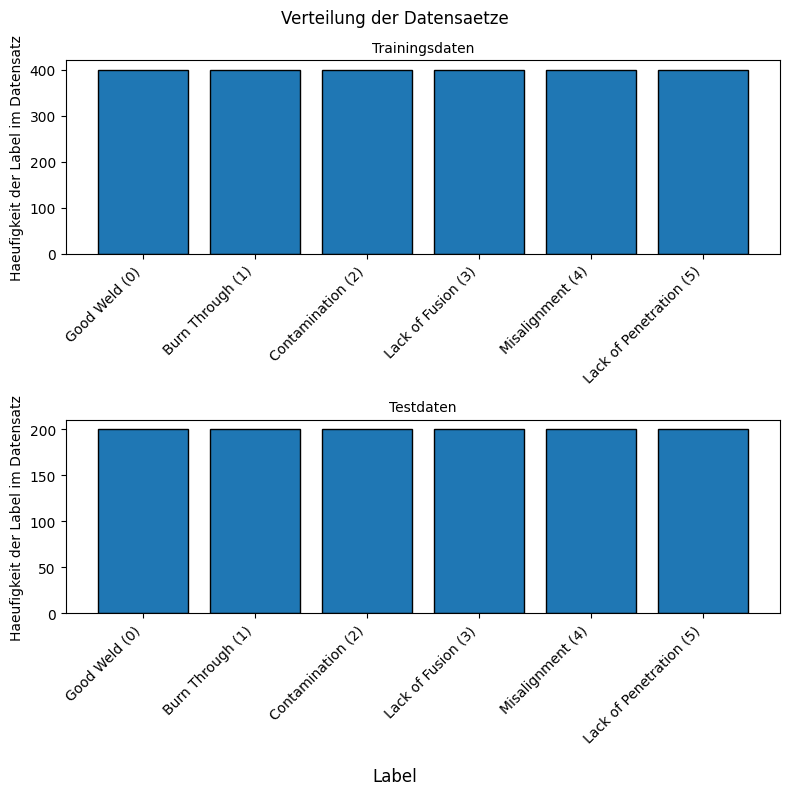

In [ ]:
orig_set.plot_distribution()


In [ ]:
for filename, label in orig_set.train_data.items():
    print(filename, label)

print(orig_set.train_dir);

170906-144958-Al 2mm/frame_01345.png 1
170906-144958-Al 2mm/frame_00135.png 1
170906-113317-Al 2mm-part3/frame_00680.png 1
170906-144958-Al 2mm/frame_00884.png 1
170906-144958-Al 2mm/frame_01364.png 1
170906-144958-Al 2mm/frame_00714.png 1
170906-144958-Al 2mm/frame_00258.png 1
170906-144958-Al 2mm/frame_00510.png 1
170906-144958-Al 2mm/frame_01396.png 1
170906-144958-Al 2mm/frame_01407.png 1
170906-144958-Al 2mm/frame_01320.png 1
170906-144958-Al 2mm/frame_00551.png 1
170906-144958-Al 2mm/frame_01416.png 1
170906-144958-Al 2mm/frame_00329.png 1
170906-144958-Al 2mm/frame_00255.png 1
170906-144958-Al 2mm/frame_01387.png 1
170906-144958-Al 2mm/frame_01150.png 1
170906-144958-Al 2mm/frame_01117.png 1
170906-144958-Al 2mm/frame_00547.png 1
170906-144958-Al 2mm/frame_01003.png 1
170906-144958-Al 2mm/frame_01480.png 1
170906-144958-Al 2mm/frame_01926.png 1
170906-144958-Al 2mm/frame_01019.png 1
170906-113317-Al 2mm-part3/frame_00663.png 1
170906-144958-Al 2mm/frame_01276.png 1
170906-144958

Shape: (974, 800)
Modus: L
  170905-115602-Al 2mm/frame_00909.png (Label: 0) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170906-144958-Al 2mm/frame_01345.png (Label: 1) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170904-112347-Al 2mm/frame_01757.png (Label: 2) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170906-150801-Al 2mm/frame_01013.png (Label: 3) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170904-141730-Al 2mm-part3/frame_00402.png (Label: 4) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170906-153326-Al 2mm-part1/frame_00283.png (Label: 5) - Size: (800, 974)


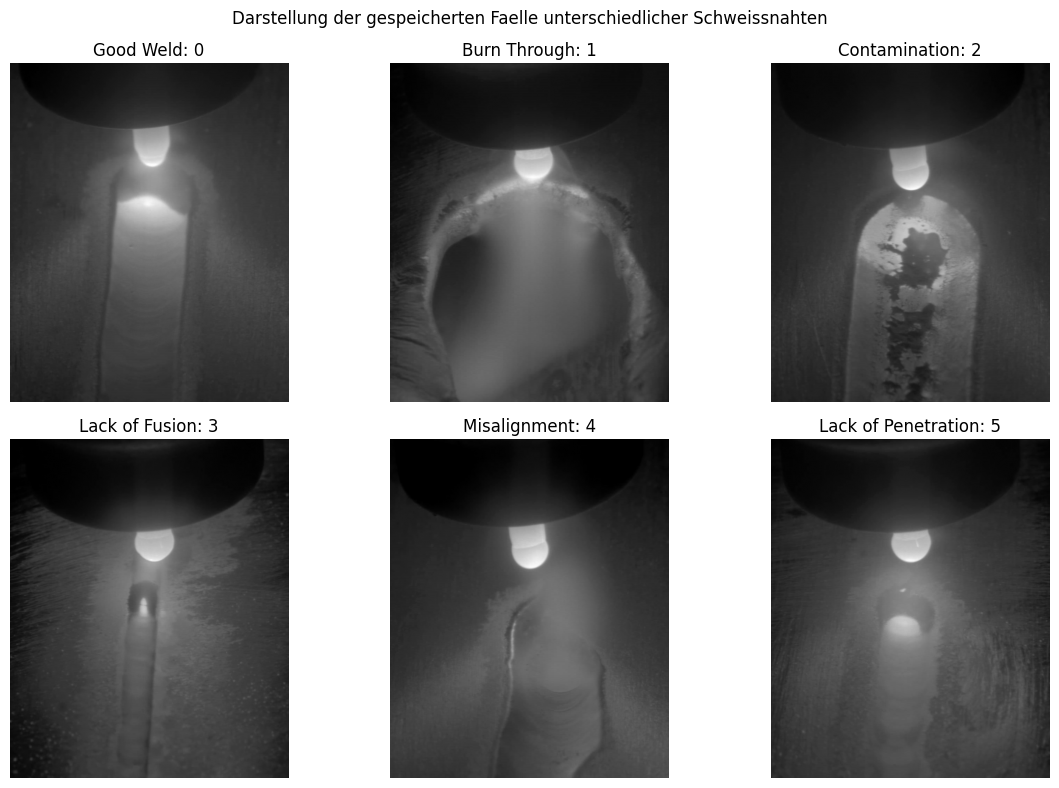

===Groesse der ersten 10 Bilder im Trainings-Datensatz===
    170906-144958-Al 2mm/frame_01345.png: (800, 974)
    170906-144958-Al 2mm/frame_00135.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00680.png: (800, 974)
    170906-144958-Al 2mm/frame_00884.png: (800, 974)
    170906-144958-Al 2mm/frame_01364.png: (800, 974)
    170906-144958-Al 2mm/frame_00714.png: (800, 974)
    170906-144958-Al 2mm/frame_00258.png: (800, 974)
    170906-144958-Al 2mm/frame_00510.png: (800, 974)
    170906-144958-Al 2mm/frame_01396.png: (800, 974)
    170906-144958-Al 2mm/frame_01407.png: (800, 974)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Darstellung der gespeicherten Faelle unterschiedlicher Schweissnahten')

#images_by_label = defaultdict(list)

lab_meaning = ['Good Weld', 'Burn Through', 'Contamination', 'Lack of Fusion', 'Misalignment', 'Lack of Penetration']
keys = [0, 1, 2, 3, 4, 5]
images_by_label = {key: [] for key in keys}
plot_idx = 0

for image_name, label in orig_set.train_data.items():
    # Namen der Bilder werden aneinander an eine Liste unter dem Label angehaengt
    images_by_label[label].append(image_name)

for label in sorted(images_by_label.keys()):
    # Zugriff auf das erste Namenselement aus images_by_label, je nach dem aktuellen key bzw. label
    image_name = images_by_label[label][0]
    # orig_set.train_dir enthaelt den uebergeordneten Dateipfad, der das Bild speichert
    image_path = orig_set.train_dir / image_name
    label_description = lab_meaning[plot_idx]
    img = Image.open(image_path)
    from numpy import asarray
    # temp= asarray(img)
    # print('temp', temp.size)
    temp = asarray(img)
    print(f"Shape: {temp.shape}")
    print(f"Modus: {img.mode}")
    # Integer Division, so dass ab 3 eine 1 als Ergebnis resultiert, vorher 0
    row = plot_idx // 3
    # Modulo Operation, um fuer 0,3 = 0; 1,4 = 1; 2,5 = 2
    col = plot_idx % 3
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'{label_description}: {label}')
    axes[row, col].axis('off')
    plot_idx += 1

    print(f"  {image_name} (Label: {label}) - Size: {img.size}")
plt.tight_layout()
plt.show()

orig_set.image_size_info("train")

In [ ]:
target_folder = r"/kaggle/working/al5083-subset-balanced-2400_128x128_Pixel"
print("\n--- Generiere Train-Subset ---")
subset = orig_set.create_balanced_subset(
    output_dir=target_folder,
    samples_per_label=400,
    seed=42,
    copy_files=True,
    split='train',
    target_size=(128,128)
)
# 2. Test-Subset erstellen (z.B. 100 Bilder pro Klasse)
print("\n--- Generiere Test-Subset ---")
test_subset = orig_set.create_balanced_subset(
    output_dir=target_folder,
    split="test",
    copy_files=True,
    samples_per_label=200,  # Wichtig: weniger als 234 wählen!
    target_size=(128,128)
)


--- Generiere Train-Subset ---
Bilder kopiert & verkleinert auf (128, 128): 2400 nach: /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/train
Subset-JSON gespeichert: /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400



--- Generiere Test-Subset ---
Bilder kopiert & verkleinert auf (128, 128): 1200 nach: /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/test
Subset-JSON gespeichert: /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/test/test.json
Gesamtzahl im Subset: 1200


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,200
1,1,200,200
2,2,200,200
3,3,200,200
4,4,200,200
5,5,200,200


In [ ]:
print(orig_set.train_class_counts)

Counter({1: 400, 2: 400, 4: 400, 0: 400, 5: 400, 3: 400})


In [ ]:
data_dir_1 = Path(r"/kaggle/working/al5083-subset-balanced-2400_128x128_Pixel")
trunc_set = DatasetManager(data_dir_1)
trunc_set.load_all()


===Trainings- und Testset (Inhalt)===

Geladene Bilddaten in /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/train/train.json: 2400
Klassenverteilung in /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/train/train.json: [(0, 400), (1, 400), (2, 400), (3, 400), (4, 400), (5, 400)]

Geladene Bilddaten in /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/test/test.json: 1200
Klassenverteilung in /kaggle/working/al5083-subset-balanced-2400_128x128_Pixel/test/test.json: [(0, 200), (1, 200), (2, 200), (3, 200), (4, 200), (5, 200)]

===Bilddateien pro Split===
Gefundene Formate in train: {'json': 1, 'png': 2400}
Train Bilder: 2400
Gefundene Formate in test: {'json': 1, 'png': 1200}
Test Bilder: 1200


({'170906-144958-Al 2mm/frame_00095.png': 1,
  '170906-144958-Al 2mm/frame_01877.png': 1,
  '170906-144958-Al 2mm/frame_01416.png': 1,
  '170906-144958-Al 2mm/frame_00044.png': 1,
  '170906-144958-Al 2mm/frame_00514.png': 1,
  '170906-144958-Al 2mm/frame_00872.png': 1,
  '170906-144958-Al 2mm/frame_00881.png': 1,
  '170906-144958-Al 2mm/frame_01426.png': 1,
  '170906-144958-Al 2mm/frame_00253.png': 1,
  '170906-144958-Al 2mm/frame_01163.png': 1,
  '170906-144958-Al 2mm/frame_01437.png': 1,
  '170906-144958-Al 2mm/frame_01461.png': 1,
  '170906-144958-Al 2mm/frame_00729.png': 1,
  '170906-144958-Al 2mm/frame_01498.png': 1,
  '170906-144958-Al 2mm/frame_00513.png': 1,
  '170906-144958-Al 2mm/frame_00328.png': 1,
  '170906-144958-Al 2mm/frame_01150.png': 1,
  '170906-144958-Al 2mm/frame_01387.png': 1,
  '170906-144958-Al 2mm/frame_01005.png': 1,
  '170906-144958-Al 2mm/frame_00248.png': 1,
  '170906-144958-Al 2mm/frame_00910.png': 1,
  '170906-144958-Al 2mm/frame_01471.png': 1,
  '170906-

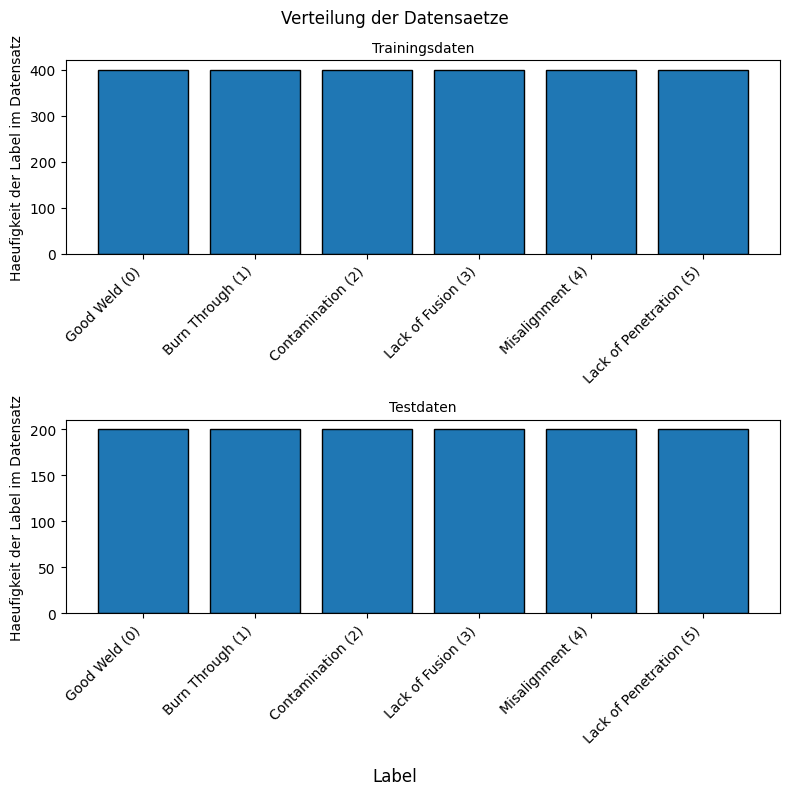

In [ ]:
trunc_set.plot_distribution()

### 3. Datenaufbereitung

Die Datenaufbereitung transformiert die Rohbilder in ein numerisches Format, das für das Machine-Learning-Modell interpretierbar ist. Das beinhaltet die Bildvorverarbeitung, die Feature-Extraktion und Feature-Transformation.

#### 3.1 Bildvorverarbeitung & Skalierung



In [ ]:
''' Funktionierendes Modell '''
import numpy as np
from PIL import Image
from pathlib import Path
from skimage.feature import hog, local_binary_pattern

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

def load_hog_lbp_dataset(dataset_dict, base_dir, pixels_per_cell=(8, 8)):
    y = []
    X = []
    
    radius = 3 # Radius fuer die zu betrachtenden Punkte um den Zentralpunkt
    n_points = 8 * radius # n_points bestimmt die Zahl der Punkte auf der Kreislinie um den Zentralpunkt
    n_bins = n_points + 2 # Angabe über die Zahl der verschiedenen Klassen, die ein Modell zu beruecksichtigen hat. Es gibt im Nachgang eine Zahl von Merkmalen wider, die signifikant für ein Label steht.

    for image_name, label in dataset_dict.items():
        image_path = base_dir / image_name # Bildpfad fuer den jeweiligen Ursprungsordner, der fur die verschiedenen Aufloesungen variiert
        with Image.open(image_path) as img:
            img_array = np.array(img)

            # Histogram of Oriented Gradients (HOG)
            # orientation gibt die Zahl der beruecksichtigten Richtungswinkel an; 
            # pixel_per_cell entspricht dem Raster aus Pixeln, deren Richtungen in einem Richtungs-Histogramm aufgezeichnet werden. Werte der Richtungspfeile werden akkumuliert und in bins gespeichert, die dann als in Summe die Gesamtrichtung und Intensität der Zelle darstellen (heller oder dunkler Stern); 
            # cells_per_block normiert die relative Helligkeit eines Richtungspfeils mit der Gesamtleuchtkraft eines Block. Der beruecksichtigte Block besteht aus hier 2x2 Zellen. 
            # block_norm gibt die Art und Weise der Normierung des Blockwertes an. 
            # transform_sqrt soll die Helligkeit im Bild bei ueberhellen Punkten stauchen und die dunklen Bereiche aufhellen, BEVOR der HOG Algorithmus die Bereiche analysiert
            hog_features = hog(img_array, orientations = 9, pixels_per_cell= pixels_per_cell, cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True, visualize=False)

            # Local Binary Pattern (LBP)
            # local_binary_pattern gibt ein array mit features zurueck, das die Anzahl in einem Bild widergibt
            lbp = local_binary_pattern(image=img_array, P = n_points, R = radius, method='uniform')
            # Das Histogramm zaehlt die Ergebnisse der aufgetretenen Klassen, die mittels dem Parameter 'density' in Dezimalzahlen umgewandelt werden und zusammen in Summe 1 ergeben
            lpb_hist, _ = np.histogram(lbp.ravel(), bins = n_bins, range = (0, n_bins), density = True)

            # Gewonnene Features aus dem HOG und LBP werden zusammen in einem gemeinsamen Feature-Vektor gebuendelt
            combined_features = np.hstack([hog_features, lpb_hist])
            # X erhaelt zum ende 2400 anteile fuer bspw. den Trainingsdatensatz
            X.append(combined_features)
            y.append(label)
    return np.array(X), np.array(y) 
 

### 4. Modellbildung



In [ ]:
# 2. Hilfsfunktion für das Training und die Evaluation (2 oder 6 Klassen)
def train_and_evaluate_model(X_train, y_train, X_test, y_test, num_classes, subset_train, resolution):
    print(f"\n   --- Training gestartet für {num_classes} Klassen ---")
    
    # Setzen der Labels (Binär: 0 = Gut, 1 = Defekt)
    if num_classes == 2:
        y_train_mapped = np.where(y_train > 0, 1, 0)
        y_test_mapped = np.where(y_test > 0, 1, 0)
        display_labels = ["Good Weld", "Defective"]
    else: # 6 Klassen 
        y_train_mapped = y_train
        y_test_mapped = y_test
        display_labels = lab_meaning
        
    # Pipeline & GridSearch
    pipeline = Pipeline([
        ("scaler", MinMaxScaler()), # Normalisierung der Feature auf einen Wertebereich von [0, 1] 
        ("pca", PCA(n_components=120, random_state=42)), # Limitierung der Hauptkomponentenzahl auf 120 
        ("svm", SVC(kernel="rbf", class_weight='balanced'))
    ])
    param_grid = {
        "svm__C": [0.1, 0.5, 1, 2],
        "svm__gamma": ["scale", "auto"]
    }
    # CrossValidation mit Standard KFold weist die Möglichkeit auf, dass die im Training verwendeten Daten aus dem gleichen Ordner wie die Testdaten zur CrossValidation stammen. Ein Ordner ist bei GroupKFold somit entweder immer im Trainings- oder im Validierungs-Split.
    train_groups = [Path(rel_path).parts[0] for rel_path in subset_train.keys()]
    cv_groups = GroupKFold(n_splits=5)
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=cv_groups,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X_train, y_train_mapped, groups=train_groups)
    
    print(f"    Beste Parameter: {grid.best_params_}")
    print(f"    Bester CV-Score: {grid.best_score_:.4f}")
    
    # Vorhersage & Report
    y_pred = grid.predict(X_test)
    test_accuracy = accuracy_score(y_test_mapped, y_pred)
    print(f"    Genauigkeit auf Testset: {test_accuracy:.2%}\n")
    print(classification_report(y_test_mapped, y_pred, target_names=display_labels))
    
    # Confusion Matrix plotten
    cm = confusion_matrix(y_test_mapped, y_pred)
    plt.figure(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=plt.gca())
    plt.title(f"Confusion Matrix ({num_classes} Klassen, {resolution[0]}x{resolution[1]} Pixel)")
    plt.tight_layout()
    plt.show()
    
    return test_accuracy, grid.best_score_

In [ ]:
def analyze_pca_variance(X, variance_threshold=0.95):
    # Features standardisieren
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA fitten
    pca = PCA()
    pca.fit(X_scaled)
    
    # Kumulative erklärte Varianz berechnen
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    
    # Finden, wie viele Komponenten benötigt werden
    n_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    variance_covered = cumulative_variance[n_components - 1] * 100
    
    print(f"=== PCA Varianz Analyse ===")
    print(f"Gesamtanzahl ursprünglicher Features: {X.shape[1]}")
    print(f"Benötigte Komponenten für >= {variance_threshold*100}% Varianz: {n_components}")
    print(f"Tatsächlich abgedeckte Varianz mit {n_components} Komponenten: {variance_covered:.2f}%")
    
    # Plot erstellen
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', markersize=2)
    plt.axhline(y=variance_threshold, color='r', linestyle='--', label=f'{variance_threshold*100}% Varianz')
    plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} Komponenten')
    plt.xlabel('Anzahl der Hauptkomponenten')
    plt.ylabel('Kumulative erklärte Varianz')
    plt.title('Kumulative erklärte Varianz vs. Anzahl der Komponenten')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return n_components, cumulative_variance

# Führe die Varianz-Analyse aus (X_train muss vorher in Zelle 10 geladen worden sein)
#n_comp, cum_var = analyze_pca_variance(X_train_features, variance_threshold=0.95)


NameError: name 'X_train_features' is not defined


 STARTE PROZESS FÜR AUFLÖSUNG: 128x128
Bilder kopiert & verkleinert auf (128, 128): 2400 nach: /kaggle/working/subset_128x128/train
Subset-JSON gespeichert: /kaggle/working/subset_128x128/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400


Bilder kopiert & verkleinert auf (128, 128): 1200 nach: /kaggle/working/subset_128x128/test
Subset-JSON gespeichert: /kaggle/working/subset_128x128/test/test.json
Gesamtzahl im Subset: 1200


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,200
1,1,200,200
2,2,200,200
3,3,200,200
4,4,200,200
5,5,200,200


Extrahiere Features (HOG + LBP) einmalig für diese Auflösung...

   --- Training gestartet für 6 Klassen ---
    Beste Parameter: {'svm__C': 0.1, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.2490
    Genauigkeit auf Testset: 47.25%

                     precision    recall  f1-score   support

          Good Weld       0.47      0.78      0.59       200
       Burn Through       0.52      0.67      0.59       200
      Contamination       0.50      0.01      0.01       200
     Lack of Fusion       0.62      0.62      0.62       200
       Misalignment       0.14      0.12      0.13       200
Lack of Penetration       0.52      0.64      0.57       200

           accuracy                           0.47      1200
          macro avg       0.46      0.47      0.42      1200
       weighted avg       0.46      0.47      0.42      1200



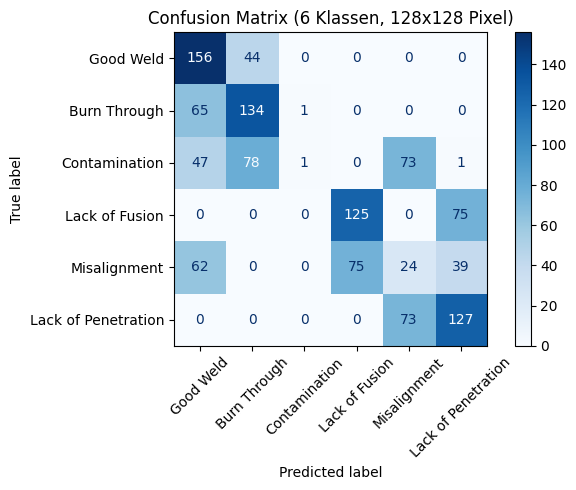


   --- Training gestartet für 2 Klassen ---
    Beste Parameter: {'svm__C': 0.1, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.6311
    Genauigkeit auf Testset: 90.92%

              precision    recall  f1-score   support

   Good Weld       0.78      0.63      0.70       200
   Defective       0.93      0.96      0.95      1000

    accuracy                           0.91      1200
   macro avg       0.86      0.80      0.82      1200
weighted avg       0.90      0.91      0.91      1200



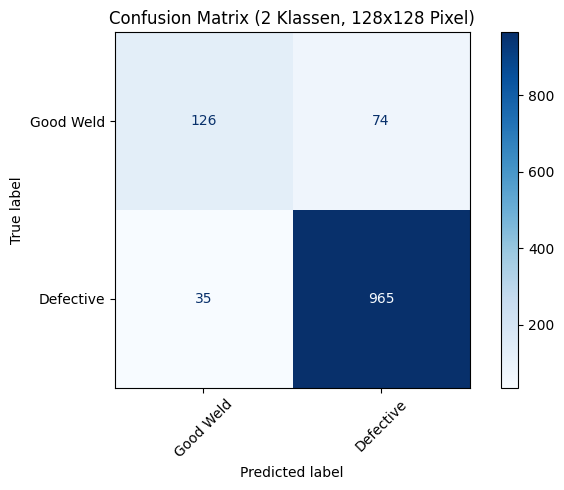


 STARTE PROZESS FÜR AUFLÖSUNG: 256x256
Bilder kopiert & verkleinert auf (256, 256): 2400 nach: /kaggle/working/subset_256x256/train
Subset-JSON gespeichert: /kaggle/working/subset_256x256/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400


Bilder kopiert & verkleinert auf (256, 256): 1200 nach: /kaggle/working/subset_256x256/test
Subset-JSON gespeichert: /kaggle/working/subset_256x256/test/test.json
Gesamtzahl im Subset: 1200


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,200
1,1,200,200
2,2,200,200
3,3,200,200
4,4,200,200
5,5,200,200


Extrahiere Features (HOG + LBP) einmalig für diese Auflösung...

   --- Training gestartet für 6 Klassen ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.2628
    Genauigkeit auf Testset: 47.42%

                     precision    recall  f1-score   support

          Good Weld       0.53      0.78      0.63       200
       Burn Through       0.59      0.88      0.70       200
      Contamination       0.08      0.02      0.03       200
     Lack of Fusion       0.90      0.40      0.55       200
       Misalignment       0.00      0.00      0.00       200
Lack of Penetration       0.41      0.77      0.53       200

           accuracy                           0.47      1200
          macro avg       0.42      0.47      0.41      1200
       weighted avg       0.42      0.47      0.41      1200



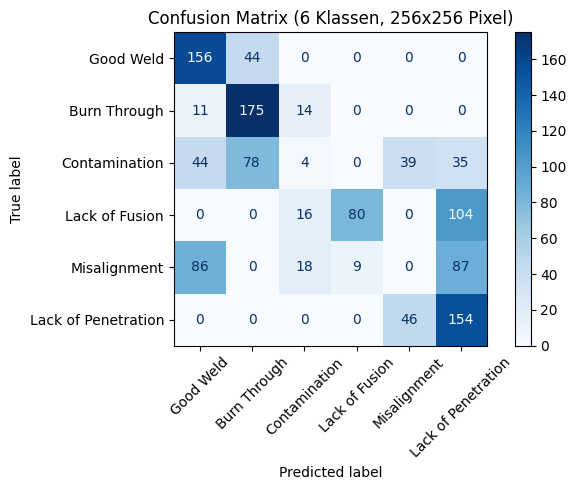


   --- Training gestartet für 2 Klassen ---
    Beste Parameter: {'svm__C': 0.1, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.6303
    Genauigkeit auf Testset: 93.92%

              precision    recall  f1-score   support

   Good Weld       1.00      0.64      0.78       200
   Defective       0.93      1.00      0.96      1000

    accuracy                           0.94      1200
   macro avg       0.97      0.82      0.87      1200
weighted avg       0.94      0.94      0.93      1200



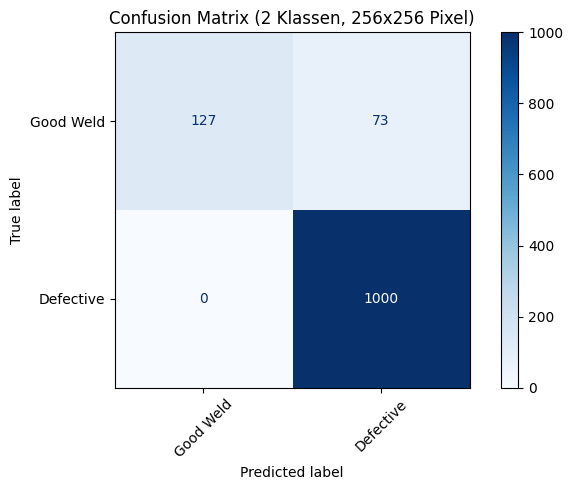


============================== ZUSAMMENFASSUNG ALLER LÄUFE ==============================

Auflösung: 128x128
  -> 6_classes  | CV-Score (F1): 0.2490 | Test-Genauigkeit: 47.25%
  -> 2_classes  | CV-Score (F1): 0.6311 | Test-Genauigkeit: 90.92%

Auflösung: 256x256
  -> 6_classes  | CV-Score (F1): 0.2628 | Test-Genauigkeit: 47.42%
  -> 2_classes  | CV-Score (F1): 0.6303 | Test-Genauigkeit: 93.92%


In [ ]:
# Definition der Auflösungs-Experimente
experiments = [
    {"resolution": (128, 128), "pixels_per_cell": (8, 8)},
    {"resolution": (256, 256), "pixels_per_cell": (16, 16)}
]
results = {}
for exp in experiments:
    res = exp["resolution"]
    cell_size = exp["pixels_per_cell"]
    res_key = f"{res[0]}x{res[1]}"
    results[res_key] = {}
    
    print("\n" + "="*70)
    print(f" STARTE PROZESS FÜR AUFLÖSUNG: {res_key}")
    print("="*70)
    
    # Pfad erstellen und Bilder anpassen
    output_dir = Path(f"/kaggle/working/subset_{res[0]}x{res[1]}")
    subset_train, _ = orig_set.create_balanced_subset(output_dir, "train", samples_per_label=400, target_size=res, copy_files=True)
    subset_test, _ = orig_set.create_balanced_subset(output_dir, "test", samples_per_label=200, target_size=res, copy_files=True)
    
    # y_train und y_test sind je die Label
    # X_train und X_test beinhalten jeweils die Features, die zur Beschreibung der Bilder notwendig sind
    print("Extrahiere Features (HOG + LBP) einmalig für diese Auflösung...")
    X_train, y_train = load_hog_lbp_dataset(subset_train, output_dir / "train", cell_size)
    X_test, y_test = load_hog_lbp_dataset(subset_test, output_dir / "test", cell_size)
    
    if res_key == "256x256":
        print("\n--- Starte einmalige PCA-Varianzanalyse für die Dokumentation ---")
    # Hier rufen wir deine Funktion aus Zelle X20 auf
    analyze_pca_variance(X_train, variance_threshold=0.8)

    # Lauf für 6 Klassen und 2 Klassen ausführen
    for num_cls in [6, 2]:
        test_acc, cv_score = train_and_evaluate_model(
            X_train, y_train, X_test, y_test, 
            num_classes=num_cls, 
            subset_train=subset_train, 
            resolution=res
        )
        results[res_key][f"{num_cls}_classes"] = {"test_acc": test_acc, "cv_score": cv_score}
# Zusammenfassung der Ergebnisse ausgeben
print("\n" + "="*30 + " ZUSAMMENFASSUNG ALLER LÄUFE " + "="*30)

for res_key, classes_dict in results.items():
    print(f"\nAuflösung: {res_key}")
    for cls_key, metrics in classes_dict.items():
        print(f"  -> {cls_key:10s} | CV-Score (F1): {metrics['cv_score']:.4f} | Test-Genauigkeit: {metrics['test_acc']:.2%}")

In [ ]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lab_meaning)

# fig, ax = plt.subplots(figsize=(10, 8))
# disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
# plt.title('Confusion Matrix - 120 Principal Components - 128 x 128 Pixels - GroupKFold')
# plt.tight_layout()
# plt.savefig('Confusion Matrix - 120 Principal Components - 128 x 128 Pixels - GroupKFold.png')
# plt.show()

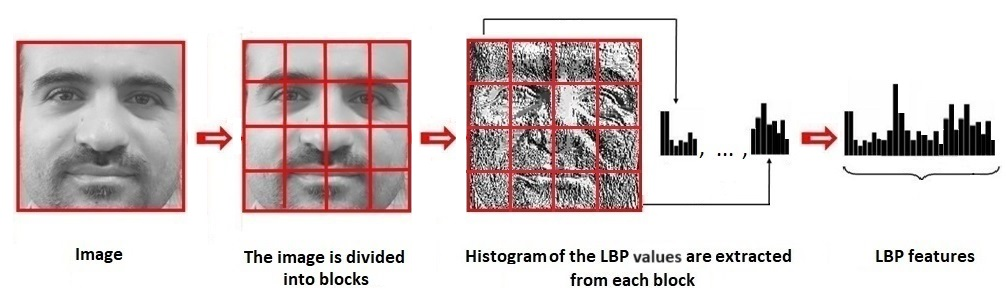

Pixelaufloesung 64 x 64
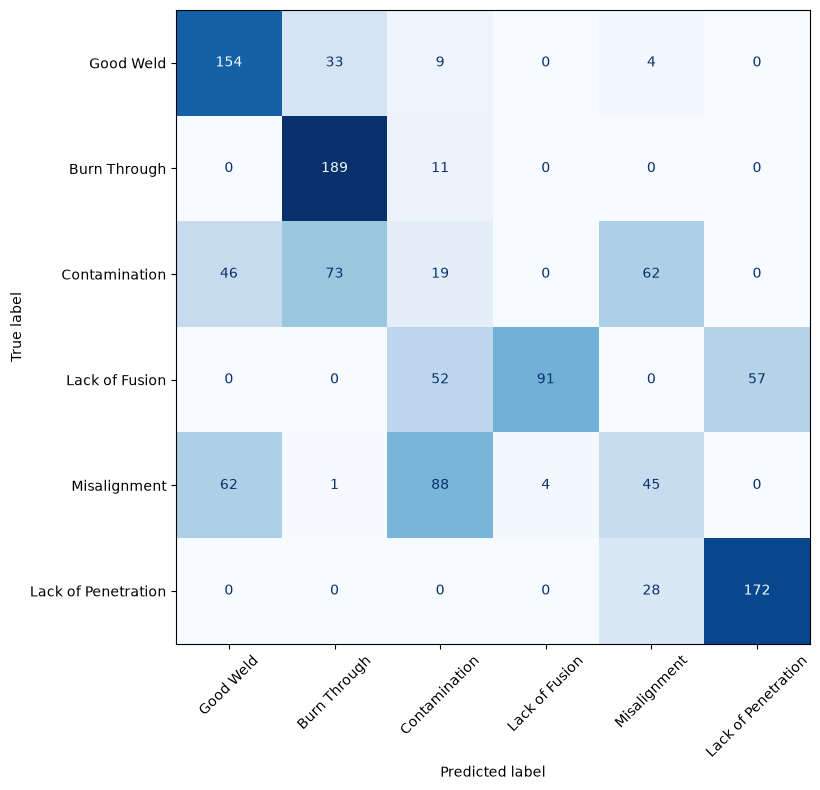